# ABM Simulation — Post-Refactor Analysis

Visual check of the ZI + FT + MM + CCP-tier model under calm vs stressed regimes.
Exogenous V_t is the Merton jump-diffusion path (`data/fv_{regime}.csv`).
Run-all to regenerate. See `claudereadme.md` for the locked agent spec.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from model.globals import ModelParams, V0
from model.simulation import Simulation
from model.agents import (FundamentalTrader, ZeroIntelligenceTrader,
                          BankingClearingMember, NonBankingClearingMember)
from run_simulation import build_traders

N_DAYS  = 20
N_STEPS = 78 * N_DAYS
SEED    = 42

In [2]:
def run_regime(stressed: bool):
    regime = "stressed" if stressed else "calm"
    p = ModelParams(
        n_zi=0, n_fundamental=0, n_mm=0,
        n_bcm=15, n_bcm_mm=8, n_bcm_with_clients=8, n_nbcm=5,
        clients_per_book=6, client_book_ft=3, client_book_zi=3,
        v0=V0[regime], tick_size=0.25, dt_minutes=5.0, order_ttl=2,
        zi_alpha=0.15, zi_mu=0.025, zi_delta=0.025, p_zi=0.30,
        ft_alpha=0.5, ft_sigma_c=10.0, ft_threshold_bps=50.0,
        mm_qty=50, mm_p_edge=4, mm_inventory_limit=1000, mm_inventory_safe=500,
        stressed=stressed,
    )
    traders = build_traders(p, seed=SEED)
    sim = Simulation(p, traders, seed=SEED)
    hist = pd.DataFrame(sim.run(N_STEPS))
    return p, traders, sim, hist

results = {r: run_regime(r == "stressed") for r in ["calm", "stressed"]}
for r, (p, traders, sim, h) in results.items():
    print(f"{r:9s}: {len(h)} steps, sigma_FT=${p.sigma_fundamental:7.2f}, "
          f"V0={p.v0:.0f}, agents={len(traders)}")

calm     : 1560 steps, sigma_FT=$  23.16, V0=2501, agents=98
stressed : 1560 steps, sigma_FT=$ 178.54, V0=3234, agents=98


## 1 · Mid price vs fundamental V_t

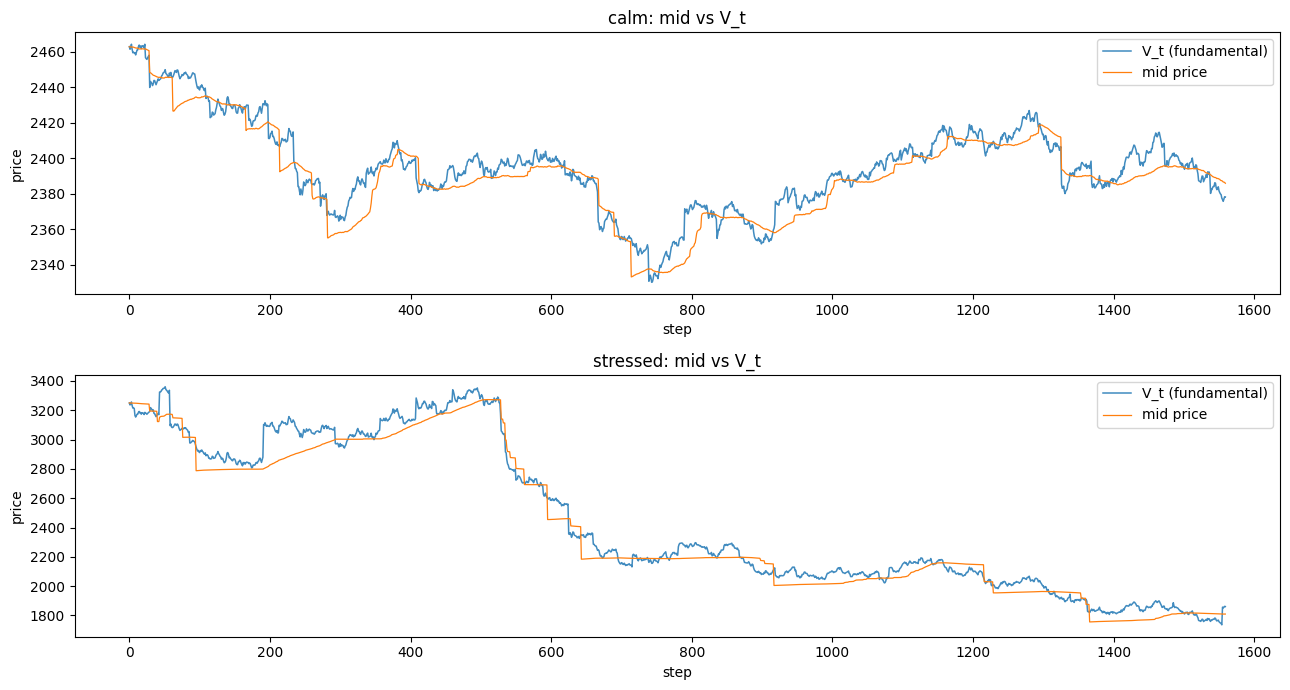

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, (r, (p, traders, sim, h)) in zip(axes, results.items()):
    ax.plot(h["t"], h["fundamental"], label="V_t (fundamental)", lw=1.1, alpha=0.85)
    ax.plot(h["t"], h["mid_price"],   label="mid price", lw=0.9)
    ax.set_title(f"{r}: mid vs V_t"); ax.set_xlabel("step"); ax.set_ylabel("price")
    ax.legend(loc="best")
plt.tight_layout(); plt.show()

## 2 · Spread and volume

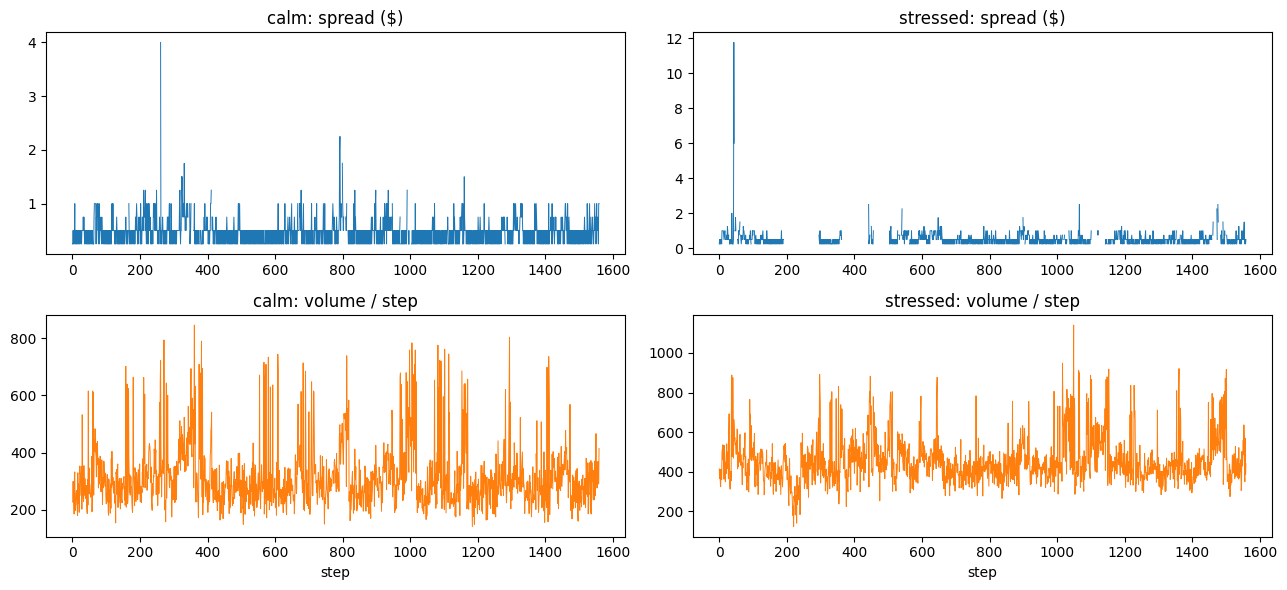

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for col, (r, (p, traders, sim, h)) in enumerate(results.items()):
    axes[0, col].plot(h["t"], h["spread"], lw=0.7)
    axes[0, col].set_title(f"{r}: spread ($)")
    axes[1, col].plot(h["t"], h["volume"], lw=0.7, color="tab:orange")
    axes[1, col].set_title(f"{r}: volume / step"); axes[1, col].set_xlabel("step")
plt.tight_layout(); plt.show()

## 3 · Return moments and distribution

,mid_ret_std,V_ret_std,mid_V_ratio,corr_V_mid,ret_kurtosis,acf_r_1,acf_absr_1,mean_spread,mean_volume
calm,0.00063,0.00093,0.67487,0.95141,136.82375,0.06928,0.03157,0.46946,317.16538
stressed,0.00552,0.00656,0.84117,0.98999,174.89097,0.00563,-0.00898,0.52828,454.13077


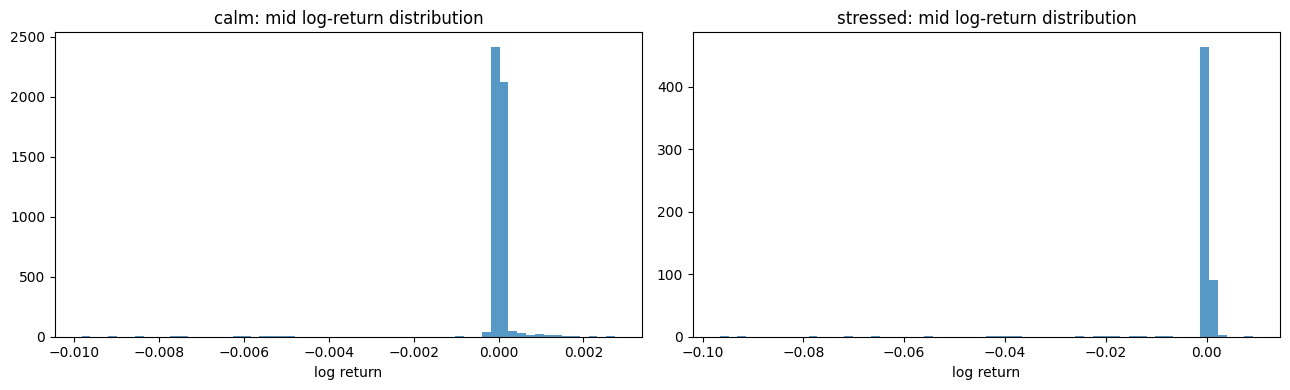

In [5]:
def moments(h):
    m = h["mid_price"].replace(0, np.nan)
    v = h["fundamental"]
    mask = m.notna().values
    lr  = np.diff(np.log(m.values[mask]))
    vlr = np.diff(np.log(v.values))
    corr = np.corrcoef(v.values[mask], m.values[mask])[0, 1] if mask.sum() > 1 else np.nan
    return dict(
        mid_ret_std  = lr.std(),
        V_ret_std    = vlr.std(),
        mid_V_ratio  = lr.std() / vlr.std(),
        corr_V_mid   = corr,
        ret_kurtosis = pd.Series(lr).kurtosis(),
        acf_r_1      = pd.Series(lr).autocorr(1),
        acf_absr_1   = pd.Series(np.abs(lr)).autocorr(1),
        mean_spread  = h["spread"].mean(),
        mean_volume  = h["volume"].mean(),
    )

summary = pd.DataFrame({r: moments(h) for r, (_, _, _, h) in results.items()}).T
display(summary.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (r, (p, traders, sim, h)) in zip(axes, results.items()):
    m = h["mid_price"].replace(0, np.nan)
    lr = np.diff(np.log(m.dropna().values))
    ax.hist(lr, bins=60, density=True, alpha=0.75)
    ax.set_title(f"{r}: mid log-return distribution"); ax.set_xlabel("log return")
plt.tight_layout(); plt.show()

## 4 · Agent state — FT inventory and CM capital ratios

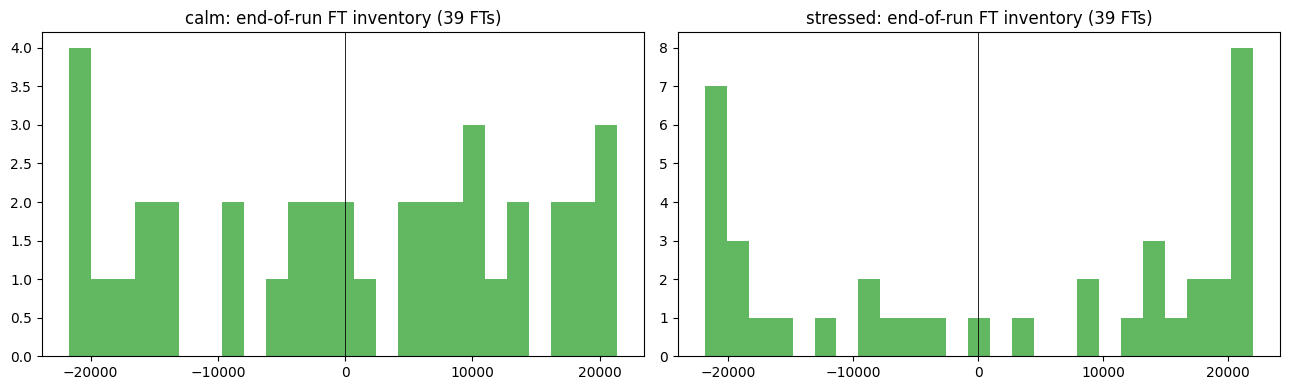


calm: CM capital ratios at final mid=2386.00 (floor 0.08)
  BCM   market_maker  agent   0  cap_ratio=8.381e+01
  BCM   market_maker  agent   7  cap_ratio=8.828e+01
  BCM   market_maker  agent  14  cap_ratio=1.547e+02
  BCM   market_maker  agent  21  cap_ratio=8.090e+01
  BCM   market_maker  agent  28  cap_ratio=1.893e+02
  BCM   market_maker  agent  35  cap_ratio=9.646e+01
  BCM   market_maker  agent  42  cap_ratio=1.336e+02
  BCM   market_maker  agent  49  cap_ratio=1.032e+02
  BCM   fundamental   agent  56  cap_ratio=6.481e+02
  BCM   fundamental   agent  57  cap_ratio=1.995e+02
  BCM   fundamental   agent  58  cap_ratio=1.924e+03
  BCM   fundamental   agent  59  cap_ratio=1.319e+03
  BCM   fundamental   agent  60  cap_ratio=1.386e+02
  BCM   fundamental   agent  61  cap_ratio=1.380e+02
  BCM   fundamental   agent  62  cap_ratio=2.550e+02
  NBCM  -             agent  63  cap_ratio=7.286e-02
  NBCM  -             agent  70  cap_ratio=1.258e-01
  NBCM  -             agent  77  cap_rat

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (r, (p, traders, sim, h)) in zip(axes, results.items()):
    ft_inv = [t.inventory for t in traders if isinstance(t, FundamentalTrader)]
    ax.hist(ft_inv, bins=25, alpha=0.75, color="tab:green")
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{r}: end-of-run FT inventory ({len(ft_inv)} FTs)")
plt.tight_layout(); plt.show()

for r, (p, traders, sim, h) in results.items():
    final_mid = h["mid_price"].dropna().iloc[-1]
    print(f"\n{r}: CM capital ratios at final mid={final_mid:.2f} (floor {p.cap_ratio_floor})")
    for t in traders:
        if isinstance(t, (BankingClearingMember, NonBankingClearingMember)):
            mode = getattr(t, "mode", "-")
            cr = t.capital_ratio(final_mid, sim.traders_by_id)
            print(f"  {t.cm_type:5s} {mode:13s} agent {t.agent_id:3d}  cap_ratio={cr:.3e}")
    tot = sum(t.inventory for t in traders)
    print(f"  total inventory across all agents = {tot}  (should be 0)")

## Notes

- **Mid vs V_t**: mid should track V_t (calm corr ≈ 0.93, stressed ≈ 0.88 at `ft_alpha=0.5`). If mid looks flat while V_t moves, the MM/FT flow balance is off — raise `ft_alpha` or lower `mm_qty`.
- **Return kurtosis** is currently high (≈ 130–150) vs empirical ES 5-min (~10–15) — driven by the ODD jump intensity and LOB microstructure; expected to compress under agent calibration.
- **Capital ratios** sit far above the 0.08 floor (no margin layer yet — Stage 4). `total inventory = 0` is the conservation check.
- `ft_alpha=0.5` is a hand-found non-degenerate operating point, **not calibrated** — the agent-calibration loop will pin it.